In [4]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from PIL import Image
from sklearn.metrics import classification_report

In [5]:
gpus = tf.config.list_physical_devices('GPU')

print("Num GPUs Available: ", len(gpus))

Num GPUs Available:  1


In [6]:
img_dir = "/kaggle/input/datasets/omarabdelazez2004/eyediseasedataset/images"
img_sz = (224,224)
batch_size = 64

strategy = tf.distribute.MirroredStrategy()

class_names = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract', 'Myopia', 'AMD', 'Hypertension', 'Others']

LABEL_TO_INDEX = {name: i for i, name in enumerate(class_names)}

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


I0000 00:00:1783768494.947973      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
def prep_data_splits(metadata_path, val_path):
    ''' Prepare data splits for training, validation and testing.'''

    df_meta = pd.read_csv(metadata_path)
    df_val = pd.read_csv(val_path)

    val_filenames = set(df_val['filename'])

    val_df = df_meta[df_meta['filename'].isin(val_filenames)].copy()
    train_test_df = df_meta[~df_meta['filename'].isin(val_filenames)].copy()

    train_df, test_df = train_test_split(train_test_df, 
                                         test_size= 0.1,
                                         stratify=train_test_df['unified_label'],
                                         random_state=42)
    
    print(f"Data Splits prepared:")
    print(f" - Train samples: {len(train_df)}")
    print(f" - Validation samples: {len(val_df)}")
    print(f" - Test samples: {len(test_df)}")
    
    return train_df, val_df, test_df

In [9]:
def load_preprocess(img_path, label, img_size = img_sz):
    ''' Load and preprocess images.'''

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, img_size)

    img = tf.keras.applications.resnet50.preprocess_input(img)

    one_hot_label = tf.one_hot(label, depth=len(class_names))

    return img, one_hot_label

def build_tf_dataset(df, image_dir, label_mapping, img_size=img_sz, batch_size=batch_size, shuffle=False):
    """
    Converts DataFrame of filenames and labels into tf.data.Dataset
    """

    file_paths = df['filename'].apply(lambda x: os.path.join(image_dir, x)).values
    labels = df['unified_label'].map(label_mapping).values
    
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    
    dataset = dataset.map(
        lambda path, label: load_preprocess(path, label, img_size),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df))
        
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset


In [10]:
if __name__ == "__main__":
    metadata_path = "/kaggle/input/datasets/omarabdelazez2004/eyediseasedataset/metadata.csv"
    val_path = "/kaggle/input/datasets/omarabdelazez2004/eyediseasedataset/splits/val.csv"

    train_df,val_df,test_df = prep_data_splits(metadata_path, val_path)

    # train_df['unified_label'] = train_df['unified_label'].astype(str).str.strip()
    # val_df['unified_label'] = val_df['unified_label'].astype(str).str.strip()
    # test_df['unified_label'] = test_df['unified_label'].astype(str).str.strip()

    train_ds = build_tf_dataset(train_df, img_dir, LABEL_TO_INDEX, shuffle=True)
    val_ds = build_tf_dataset(val_df, img_dir, LABEL_TO_INDEX)
    test_ds = build_tf_dataset(test_df, img_dir, LABEL_TO_INDEX)

    # for class imbalance handling, calculate class weights
    y_train = train_df['unified_label'].map(LABEL_TO_INDEX).values

    class_wweights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weight_dict = dict(enumerate(class_wweights))

    print("\nClass weights:")

    for idx, weight in class_weight_dict.items():
        print(f" - {class_names[idx]}: {weight:.4f}")

Data Splits prepared:
 - Train samples: 9577
 - Validation samples: 1197
 - Test samples: 1065

Class weights:
 - Normal: 0.3144
 - Diabetic Retinopathy: 0.3608
 - Glaucoma: 1.5898
 - Cataract: 4.3532
 - Myopia: 5.0299
 - AMD: 5.4169
 - Hypertension: 16.8609
 - Others: 1.3406


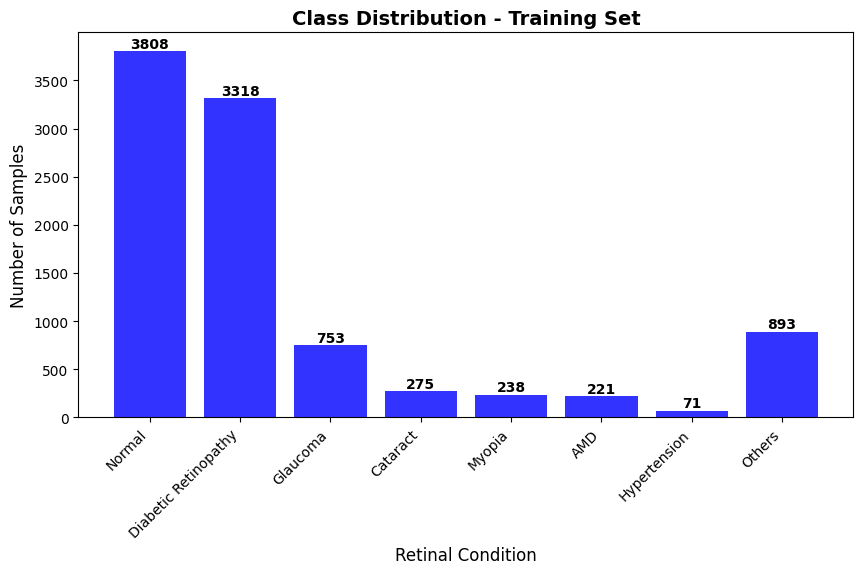

In [11]:
def plot_class_distribution(df, dataset_name="Total Dataset"):
    """Plots a bar chart showing the sample counts for each class."""
    # Count occurrences of each category
    counts = df['unified_label'].value_counts()
    
    for cls in class_names:
        if cls not in counts:
            counts[cls] = 0
            
    counts = counts.reindex(class_names)
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(counts.index, counts.values, color='blue', alpha=0.8)
    
    plt.title(f"Class Distribution - {dataset_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Retinal Condition", fontsize=12)
    plt.ylabel("Number of Samples", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Write class occurence on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.show()

# Run this visualization on the training split
plot_class_distribution(train_df, "Training Set")

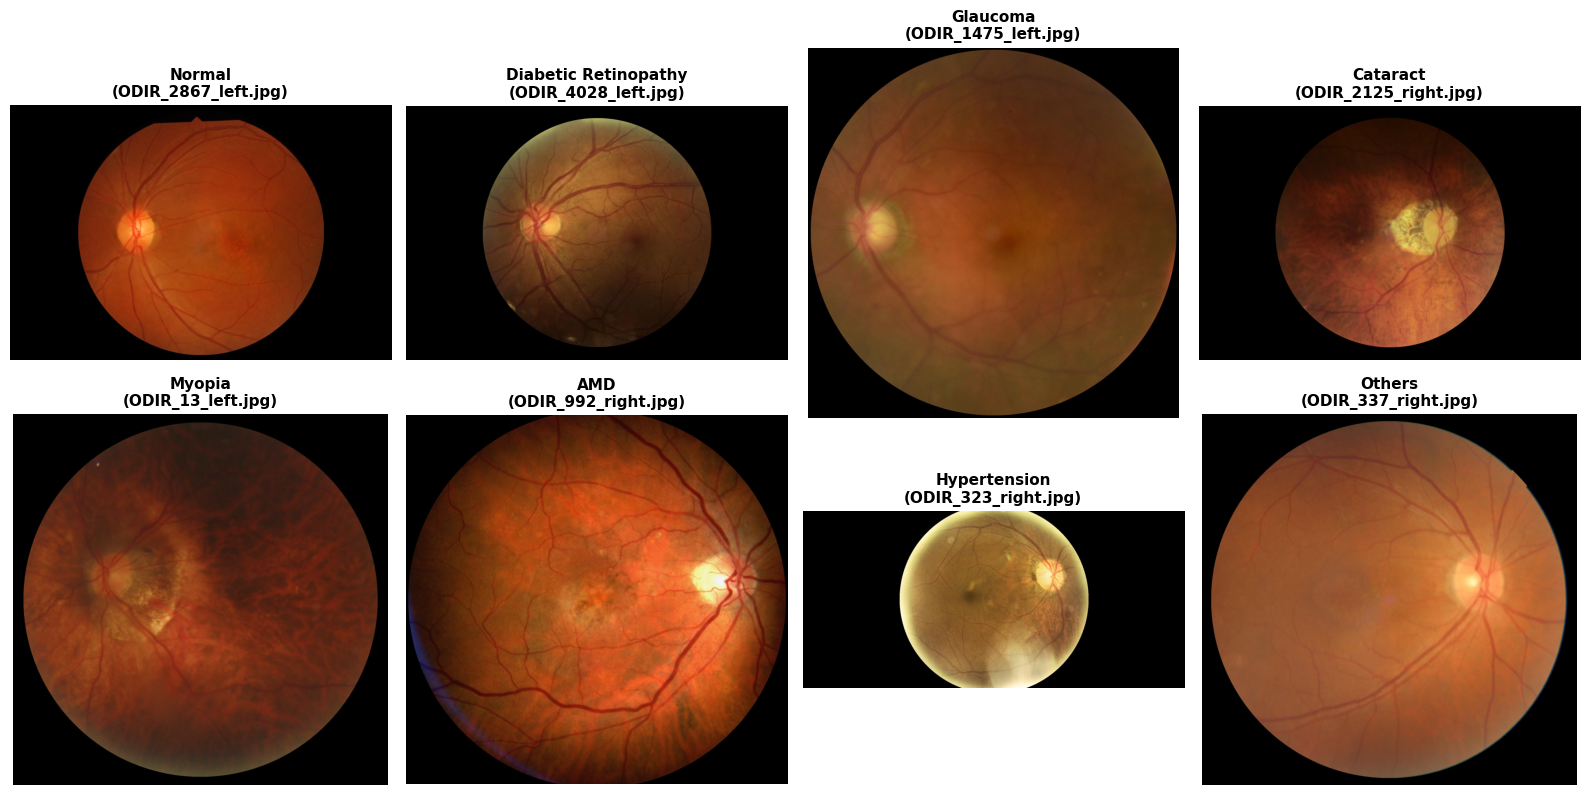

In [12]:
def visualize_sample_images(df, image_dir):
    """Displays a grid of sample fundus images representing each of the 8 classes."""
    plt.figure(figsize=(16, 8))
    
    for i, class_name in enumerate(class_names):
        sample_row = df[df['unified_label'] == class_name]
        
        if sample_row.empty:
            print(f"No sample image found for category: {class_name}")
            continue
            
        sample_row = sample_row.iloc[0]
        img_path = os.path.join(image_dir, sample_row['filename'])
              
        img = Image.open(img_path)
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{class_name}\n({sample_row['filename']})", fontsize=11, fontweight='bold')
        plt.axis('off')
            
    plt.tight_layout()
    plt.show()

visualize_sample_images(train_df, img_dir)

In [15]:
def pretrained_resnet50(num_classes, input_shape=(224, 224, 3)):
    """Custom CNN model with pre-trained ResNet50 as backbone."""
    
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    
    base_model.trainable = False 
    
    model = tf.keras.models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

resnet_model = pretrained_resnet50(num_classes=len(class_names), input_shape=(224, 224, 3))

resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy',
                              tf.keras.metrics.Precision(name='precision'),
                              tf.keras.metrics.Recall(name='recall'),
                              tf.keras.metrics.F1Score(name='f1_score', average='macro')]
                    )

resnet_model = pretrained_resnet50(input_shape=(224, 224, 3), num_classes=8)
    
resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.F1Score(name='f1_score', average='macro')]
    )
    
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',     
#     patience=3,
#     restore_best_weights=True
# )


resnet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
)

Epoch 1/50
  2/150 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.0859 - f1_score: 0.0391 - loss: 3.0008 - precision: 0.0000e+00 - recall: 0.0000e+00    

I0000 00:00:1783768657.126653     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 144s 253ms/step - accuracy: 0.3776 - f1_score: 0.3184 - loss: 1.5201 - precision: 0.7054 - recall: 0.2150 - val_accuracy: 0.4336 - val_f1_score: 0.3824 - val_loss: 1.4971 - val_precision: 0.7480 - val_recall: 0.3124
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 99s 152ms/step - accuracy: 0.4704 - f1_score: 0.4064 - loss: 1.2109 - precision: 0.7620 - recall: 0.3353 - val_accuracy: 0.4678 - val_f1_score: 0.4127 - val_loss: 1.3334 - val_precision: 0.7622 - val_recall: 0.3642
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 98s 150ms/step - accuracy: 0.4915 - f1_score: 0.4269 - loss: 1.1409 - precision: 0.7580 - recall: 0.3607 - val_accuracy: 0.4795 - val_f1_score: 0.4257 - val_loss: 1.3462 - val_precision: 0.8000 - val_recall: 0.3810
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 98s 153ms/step - accuracy: 0.5066 - f1_score: 0.4490 - loss: 1.0535 - precision: 0.7859 - recall: 0.3845 - val_accuracy: 0.4887 - val_f1_score: 0.4299 - val_loss: 1.2821 - val_precision: 0.7714 - val_recal

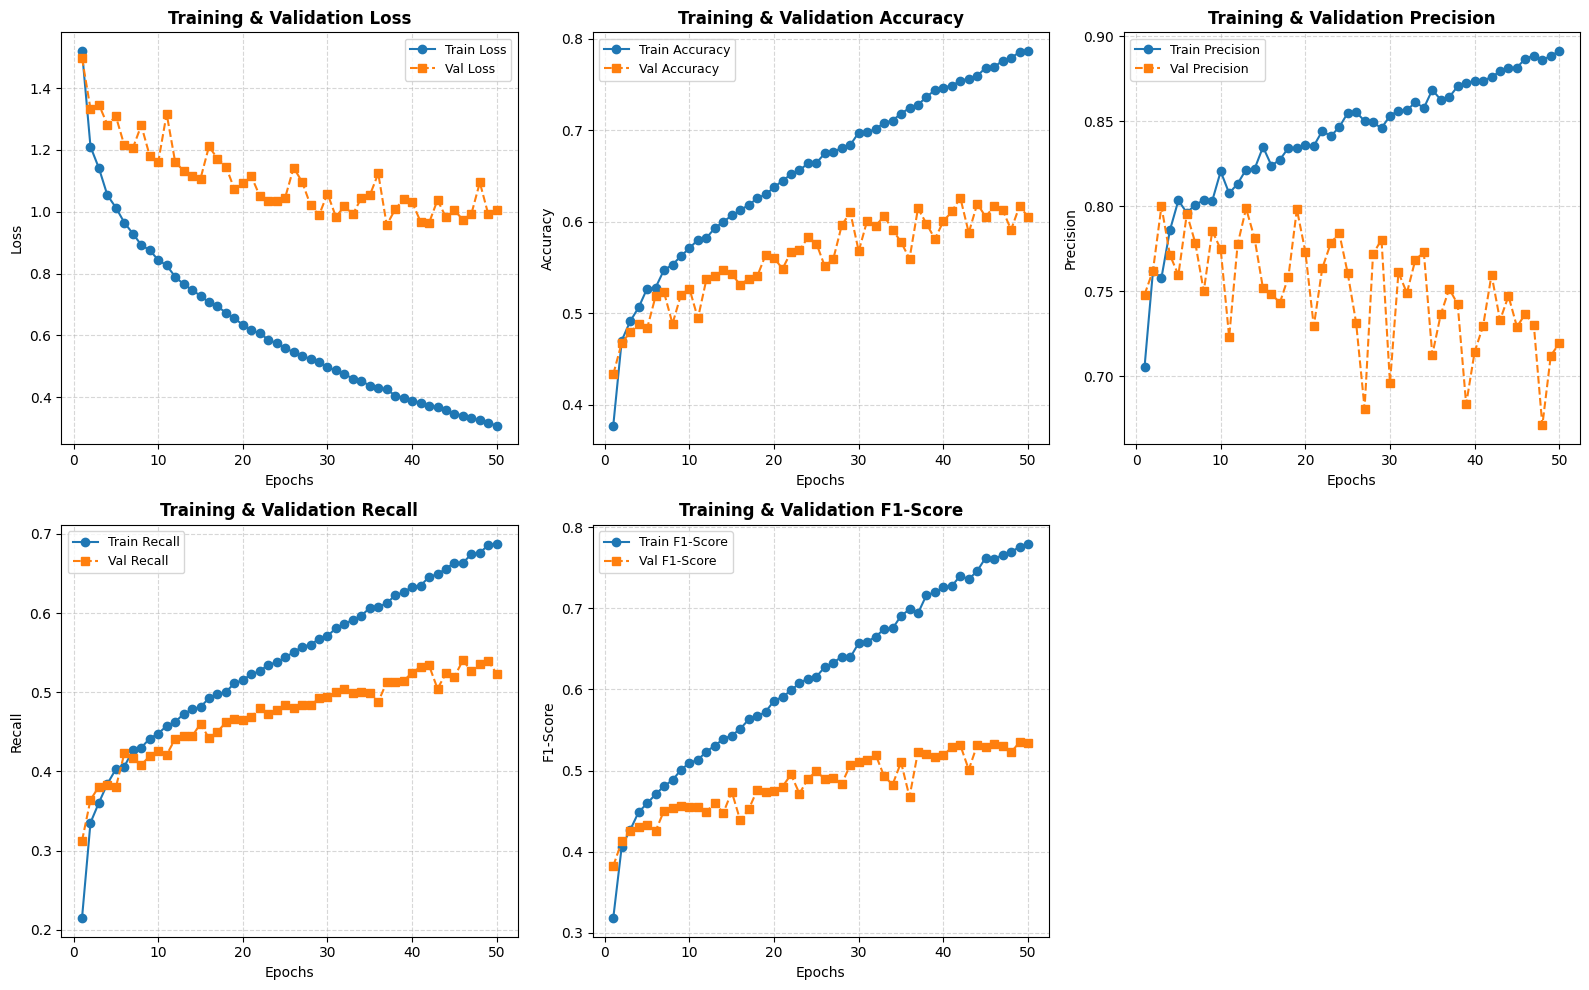

In [17]:
epochs = range(1, len(resnet_history.history['loss']) + 1)

metrics_to_plot = [
    ('loss', 'Loss'),
    ('accuracy', 'Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall'),
    ('f1_score', 'F1-Score')
]

plt.figure(figsize=(16, 10))

for i, (metric_key, metric_name) in enumerate(metrics_to_plot, 1):
    actual_key = metric_key
    if metric_key not in resnet_history.history:
        for k in resnet_history.history.keys():
            if k.endswith(metric_key) and not k.startswith('val_'):
                actual_key = k
                break
                
    plt.subplot(2, 3, i)
    
    if actual_key in resnet_history.history:
        plt.plot(epochs, resnet_history.history[actual_key], 'o-', label=f'Train {metric_name}', color='#1f77b4', linewidth=1.5)
    
    val_key = f'val_{actual_key}'
    if val_key in resnet_history.history:
        plt.plot(epochs, resnet_history.history[val_key], 's--', label=f'Val {metric_name}', color='#ff7f0e', linewidth=1.5)
        
    plt.title(f'Training & Validation {metric_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel(metric_name, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=9, loc='best')

plt.subplot(2, 3, 6).axis('off')

plt.tight_layout()
plt.show()

In [18]:
all_preds = []
all_trues = []
    
for images, labels in test_ds:
        preds = resnet_model.predict(images, verbose=0)
        pred_indices = np.argmax(preds, axis=1)
        
        if len(labels.shape) > 1 and labels.shape[-1] > 1:
            true_indices = np.argmax(labels.numpy(), axis=1)
        else:
            true_indices = labels.numpy()
            
        all_preds.extend(pred_indices)
        all_trues.extend(true_indices)
        
report = classification_report(
        all_trues, 
        all_preds, 
        target_names=class_names,
        zero_division=0
    )
    
print("\n" + "="*50)
print("            PER-CLASS CLASSIFICATION REPORT")
print("="*50)
print(report)
print("="*50)


            PER-CLASS CLASSIFICATION REPORT
                      precision    recall  f1-score   support

              Normal       0.80      0.63      0.71       423
Diabetic Retinopathy       0.88      0.55      0.68       369
            Glaucoma       0.47      0.75      0.58        84
            Cataract       0.57      0.87      0.69        31
              Myopia       0.71      0.85      0.77        26
                 AMD       0.24      0.48      0.32        25
        Hypertension       0.19      0.38      0.25         8
              Others       0.24      0.54      0.33        99

            accuracy                           0.61      1065
           macro avg       0.51      0.63      0.54      1065
        weighted avg       0.72      0.61      0.64      1065

